**Objective:** The objective of this project is to build a machine learning model that predicts whether a bank customer will subscribe to a term deposit based on their demographic information, financial background, and previous marketing campaign interactions. The project aims to analyze customer behavior and improve the effectiveness of bank marketing campaigns by identifying potential customers who are more likely to subscribe.

**Problem Statement:** Banks conduct marketing campaigns to promote term deposit subscriptions, but contacting every customer can be costly and inefficient. The challenge is to predict which customers are likely to subscribe to a term deposit using historical customer and campaign data. By applying classification techniques in machine learning, the bank can target the right customers, reduce marketing costs, and increase campaign success rates.

**Data Loading:** The dataset is loaded into Python using the Pandas library. Data loading is the first step in data analysis and machine learning, where the dataset is imported into a DataFrame for further exploration and preprocessing. After loading the dataset, functions such as .head(), .info(), and .shape() are used to inspect the data structure, check column details, and understand the number of rows and columns present in the dataset.

In [1]:
#Import required libraries
import pandas as pd
import numpy as np
from google.colab import files
uploaded = files.upload()

#Load the dataset from CSV file
df = pd.read_csv("bank.csv")

#Explore the Dataset

# Display first 5 rows of the dataset
# Helps to understand how the data looks
print("First 5 Rows of Dataset:")
print(df.head())

# Display last 5 rows of the dataset
print("\nLast 5 Rows of Dataset:")
print(df.tail())

Saving bank.csv to bank.csv
First 5 Rows of Dataset:
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  

Last 5 Rows of Dataset:
       age          j

**Data Cleaning and Preprocessing:** Data cleaning and preprocessing are important steps in machine learning because raw data may contain missing values, duplicate records, inconsistent formats, or categorical data that cannot be directly used by machine learning algorithms. The purpose of preprocessing is to prepare the dataset in a clean and structured format for accurate model training and prediction.

In this project, the dataset is first checked for missing values and duplicate entries. Duplicate rows are removed to avoid repeated information that may affect model performance. The dataset is also examined for incorrect or inconsistent data types.

Since the Bank Marketing dataset contains many categorical variables such as job, marital status, education, and contact type, these features are converted into numerical form using encoding techniques. Label Encoding or One-Hot Encoding can be applied depending on the feature type.

The target variable “y”, which contains values “yes” and “no”, is also transformed into numerical values so that the machine learning model can process it effectively.

In [2]:
#Check the number of rows and columns
#Shape = (rows, columns)
print("\nShape of Dataset:")
print(df.shape)

#Display column names
print("\nColumn Names:")
print(df.columns)

#Get complete information about dataset
#Includes data types and non-null values
print("\nDataset Information:")
print(df.info())

#Check data types of each column
print("\nData Types:")
print(df.dtypes)

#Check for missing values in each column
print("\nMissing Values:")
print(df.isnull().sum())

#Display unique values in target column
#'y' is the target variable
print("\nTarget Variable Values:")
print(df['deposit'].unique())

#Count the number of Yes and No values
print("\nTarget Variable Count:")
print(df['deposit'].value_counts())

#Check duplicate rows in dataset
print("\nDuplicate Rows:")
print(df.duplicated().sum())


Shape of Dataset:
(11162, 17)

Column Names:
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      1116

**Data Description:** The dataset used in this project contains customer information collected during a bank marketing campaign. It includes demographic details, financial information, and previous campaign interactions of customers. Features such as age, job, marital status, education, balance, housing loan, contact type, and campaign duration are used to predict whether a customer will subscribe to a term deposit.

The target variable in the dataset is “y”, which indicates whether the customer subscribed to a term deposit:

Yes → Customer subscribed
No → Customer did not subscribe

This dataset helps in understanding customer behavior and identifying factors that influence term deposit subscriptions.

The dataset has 11,162 rows and 17 columns. There are no missing values in any of the columns. There are 5,873 'no' subscriptions and 5,289 'yes' subscriptions. There are no duplicate rows in the dataset.

This information indicates that the dataset is clean in terms of missing and duplicate values, and the target variable 'deposit' is binary, which is suitable for a classification problem

In [3]:
#Import required libraries
import pandas as pd
from sklearn.preprocessing import LabelEncoder

#Check Categorical Columns

#Display data types of all columns
print("Data Types of Columns:\n")
print(df.dtypes)

#Select all categorical columns
#object' datatype means categorical/text data
categorical_columns = df.select_dtypes(include=['object']).columns

#Display categorical column names
print("\nCategorical Columns:\n")
print(categorical_columns)

#Encode Categorical Features

#Create LabelEncoder object
le = LabelEncoder()

#Apply Label Encoding on all categorical columns
for column in categorical_columns:
    #Convert text values into numerical values
    df[column] = le.fit_transform(df[column])

#Display Encoded Dataset

#Display first 5 rows after encoding
print("\nEncoded Dataset:\n")
print(df.head())

#Check updated Data Types
print("\nUpdated Data Types:\n")
print(df.dtypes)

#Verify if any categorical column still exists
remaining_categorical = df.select_dtypes(include=['object']).columns

print("\nRemaining Categorical Columns:\n")
print(remaining_categorical)

Data Types of Columns:

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

Categorical Columns:

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'deposit'],
      dtype='object')

Encoded Dataset:

   age  job  marital  education  default  balance  housing  loan  contact  \
0   59    0        1          1        0     2343        1     0        2   
1   56    0        1          1        0       45        0     0        2   
2   41    9        1          1        0     1270        1     0        2   
3   55    7        1          1        0     2476        1     0        2   
4   54    0        1          2        0      184     

**Exploratory Data Analysis:** It is an important step in the data science process where we analyze and summarize the main characteristics of the dataset before building a machine learning model. It helps us understand patterns, relationships and trends in the data.

In this project, EDA is used to gain insights into customer behavior in the bank marketing dataset. We begin by analyzing the distribution of key variables such as age, job, marital status, balance, and loan status to understand the profile of customers. This helps identify which type of customers are more likely to subscribe to a term deposit.

**Univariate Analysis** is performed to analyze each feature individually using counts, histograms, and value distributions. This helps us understand how data is spread across different categories.

**Bivariate Analysis** is performed to explore relationships between independent variables and the target variable “y”. For example, we check how job type, education level, or housing loan status affects the likelihood of subscription.

**Correlation Analysis** is also used to identify relationships between numerical variables and to understand how strongly features are related to each other and the target variable.

Through visualization techniques such as bar plots, histograms, and heatmaps, Exploratory Data Analysis provides meaningful insights that help in feature selection and improve the performance of the machine learning model.


Target Variable Count:
deposit
0    5873
1    5289
Name: count, dtype: int64


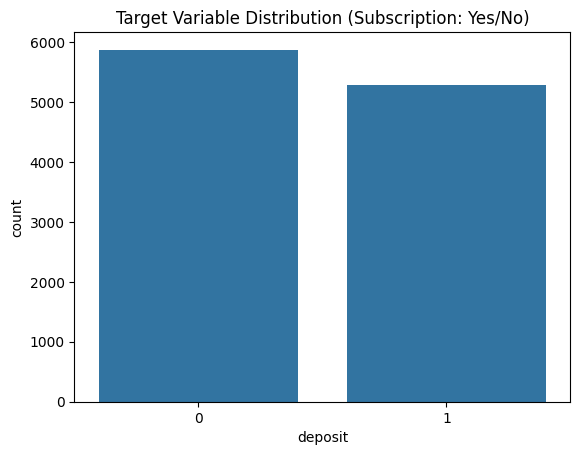

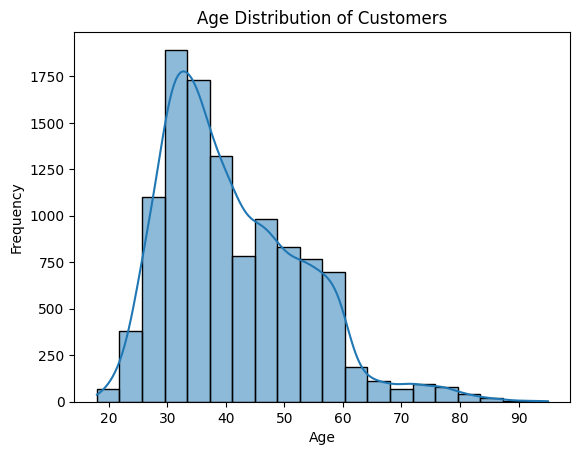

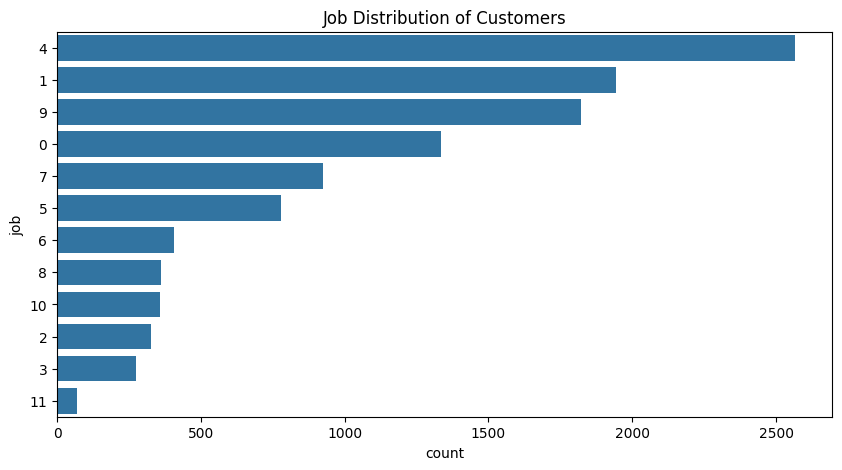

In [4]:
#Exploratory Data Analysis (EDA)

#Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Univariate Analysis

# Distribution of target variable (deposit)
print("\nTarget Variable Count:")
print(df['deposit'].value_counts())

plt.figure()
sns.countplot(x='deposit', data=df)
plt.title("Target Variable Distribution (Subscription: Yes/No)")
plt.show()

#Age distribution
plt.figure()
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

#Job distribution
plt.figure(figsize=(10,5))
sns.countplot(y='job', data=df, order=df['job'].value_counts().index)
plt.title("Job Distribution of Customers")
plt.show()

**Target Variable Distribution (Deposit):** The countplot shows that there are 5,873 customers who did not subscribe (represented by 0) and 5,289 customers who did subscribe (represented by 1). This indicates a relatively balanced dataset, which is good for training classification models.

**Age Distribution:** The histogram for 'age' illustrates the distribution of customer ages, giving us an idea of the most common age groups in the dataset.

**Job Distribution:** The countplot for 'job' displays the frequency of each job category among the customers, showing which professions are most represented.

These visualizations help us understand the individual characteristics and distributions of key features in our dataset.

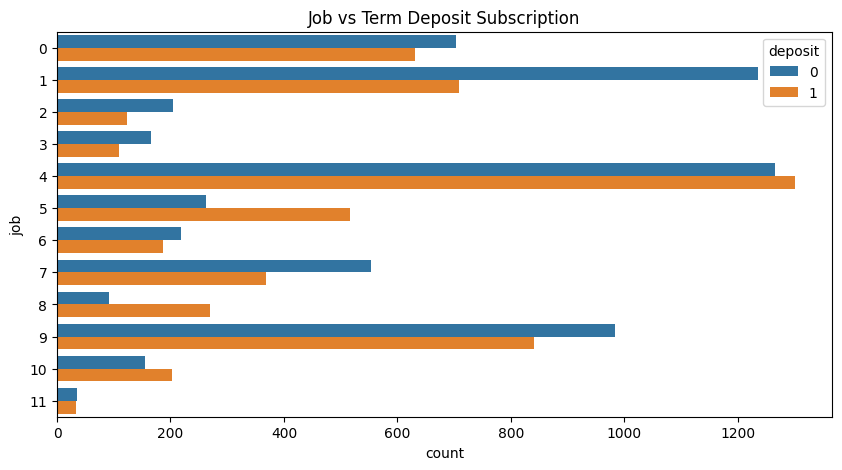

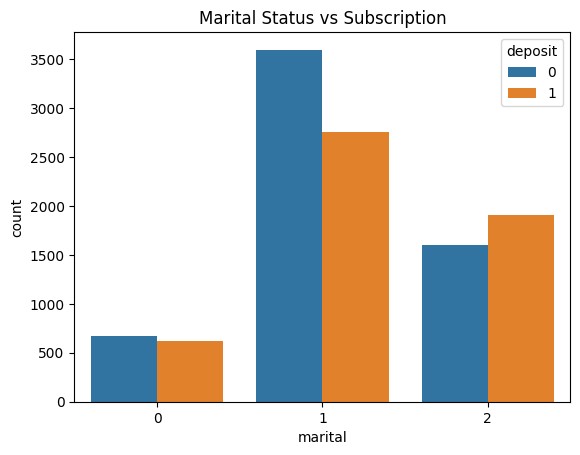

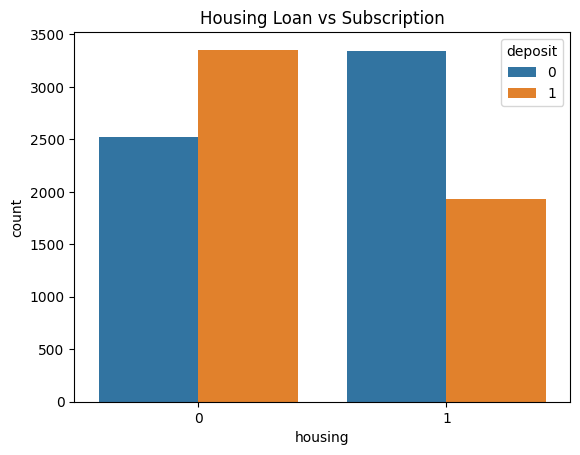

In [5]:
#Bivariate Analysis

#Job vs Subscription
plt.figure(figsize=(10,5))
sns.countplot(y='job', hue='deposit', data=df)
plt.title("Job vs Term Deposit Subscription")
plt.show()

#Marital status vs Subscription
plt.figure()
sns.countplot(x='marital', hue='deposit', data=df)
plt.title("Marital Status vs Subscription")
plt.show()

#Housing loan vs Subscription
plt.figure()
sns.countplot(x='housing', hue='deposit', data=df)
plt.title("Housing Loan vs Subscription")
plt.show()

**Job vs Term Deposit Subscription:** This plot visualizes how different job categories influence a customer's likelihood of subscribing to a term deposit.

**Marital Status vs Subscription:** This plot shows the relationship between a customer's marital status and their subscription to a term deposit.

**Housing Loan vs Subscription:** This plot illustrates how having a housing loan correlates with term deposit subscriptions.

These visualizations provide insights into which demographic and financial characteristics might make a customer more or less likely to subscribe to a term deposit.

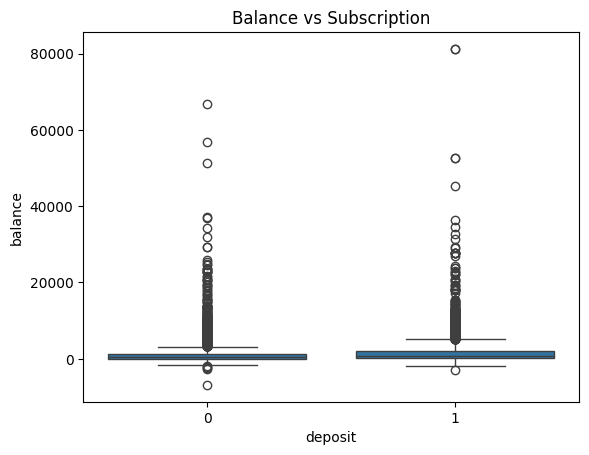

In [6]:
#Balance Analysis

plt.figure()
sns.boxplot(x='deposit', y='balance', data=df)
plt.title("Balance vs Subscription")
plt.show()

This plot visually represents the distribution of customer balance for those who subscribed to a term deposit versus those who did not. It helps in understanding if there's a significant difference in balances between these two groups, which can be a key factor in predicting subscription.

**Model Building:** In this step, a machine learning algorithm is trained to predict whether a customer will subscribe to a term deposit. The dataset is divided into:

**Independent variables (X):** Customer features such as age, job, balance, loan status, etc.

**Dependent variable (y):** Target variable indicating subscription (Yes/No)

The data is then split into:

**Training set:** Used to train the model

**Testing set:** Used to evaluate model performance on unseen data

A classification algorithm such as **Logistic Regression**, **Decision Tree**, or **Random Forest** is applied because the target variable is categorical. The model learns patterns from the training data and tries to predict whether a customer will subscribe to a term deposit.

**Model Evaluation:** After training, the model is tested using the test dataset. Its performance is evaluated using different metrics such as:

**Accuracy:** Measures the overall correctness of predictions

**Precision:** Shows how many predicted positives are actually correct

**Recall:** Measures how many actual positives were correctly identified

**F1-score:** Balanced measure of precision and recall

**Confusion Matrix:** Shows correct and incorrect predictions in matrix form

These evaluation metrics help determine how well the model is performing and whether it is reliable for real-world use.

The model building and evaluation step ensures that we not only create a predictive model but also verify its effectiveness. A good model helps the bank target the right customers, improve marketing efficiency, and increase term deposit subscriptions.

In [10]:
#Model Building: Random Forest

#Import required libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Separate Features and Target Variables

#X = independent variables (all columns except target)
#y = target variable (subscription result)
X = df.drop('deposit', axis=1)
y = df['deposit']

#Split Data into Training and Testing Set

#80% training data, 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Initialize Random Forest Model

# n_estimators = number of trees in forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

#Train The Model
rf_model.fit(X_train, y_train)

#Make Predictions
y_pred = rf_model.predict(X_test)

#Model Evaluation

#Accuracy score
print("Accuracy:", accuracy_score(y_test, y_pred))

#Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

#Classification report (precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8334079713390058

Confusion Matrix:
[[952 214]
 [158 909]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1166
           1       0.81      0.85      0.83      1067

    accuracy                           0.83      2233
   macro avg       0.83      0.83      0.83      2233
weighted avg       0.83      0.83      0.83      2233



**Accuracy:** Model has an over all accuracy of 0.833 (83.3%). The model has predicted 83.3% correct cases from the total predictions This shows that the model has good performance for classification task.

**Breakdown of Confusion Matrix**

**True Negative (952):** The model correctly predicted that the customer would not subscribe to the term deposit.

**False Positive (214):** The model incorrectly predicted that the customer would subscribe, but in reality, they did not.

**False Negative (158):** The model incorrectly predicted that the customer would not subscribe, but in reality, they did.

**True Positive (909):** The model correctly predicted that the customer would subscribe to the term deposit.

This indicates that the model is fairly balanced in predicting both classes.

**Classification Report:**

**Class 0 (No Subscription)**

**Precision: 0.86 →** When the model predicts “No”, 86% of the predictions are correct.

**Recall: 0.82 →** Out of all actual “No” cases, 82% were correctly identified.

**F1-score: 0.84 →** Indicates a well-balanced performance between precision and recall.

**Class 1 (Subscription Yes)**

**Precision: 0.81 →** When the model predicts “Yes”, 81% of the predictions are correct.

**Recall: 0.85 →** Out of all actual subscribers, 85% were correctly identified.

**F1-score: 0.83 →** Shows a good balance between precision and recall.

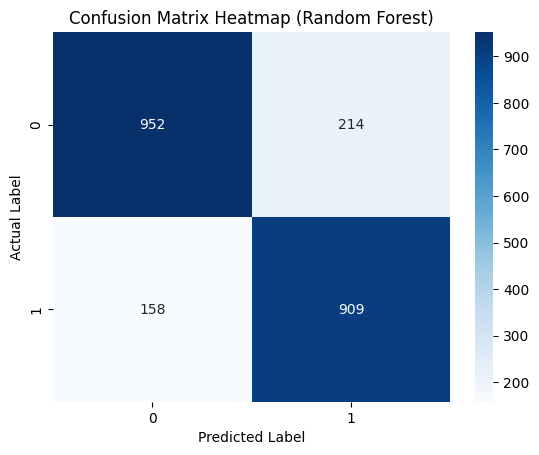

In [11]:
#Confusion Matrix Visualization (From the Given Values)

#Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Confusion Matrix Values

#From the results:
# [[952 214]
#  [158 909]]

cm = np.array([[952, 214],
               [158, 909]])

#Plot HeatMap
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

#Labels
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix Heatmap (Random Forest)")

#Show plot
plt.show()

**ROC Curve:** The ROC Curve (Receiver Operating Characteristic Curve) is a graphical tool used to evaluate the performance of a classification model, especially when the output is binary (like Yes/No, 0/1).

It shows how well a model can distinguish between two classes.

The ROC curve is plotted using two important measures:

**True Positive Rate (TPR) / Recall**: How many actual positives were correctly predicted

**False Positive Rate (FPR)**: How many negatives were incorrectly predicted as positives

The curve is plotted between** TPR (Y-axis) **and **FPR (X-axis)**

A better model has a curve that moves closer to the top-left corner.

Along with ROC, we use **AUC score:** **(Area Under Curve)**

**AUC = 1 →** Perfect model

**AUC = 0.5 →** No discrimination (random model)

**Higher AUC →** Better model performance

In this project, ROC curve helps to check whether the Random Forest model is correctly identifying customers who will subscribe and how well it avoids false predictions.

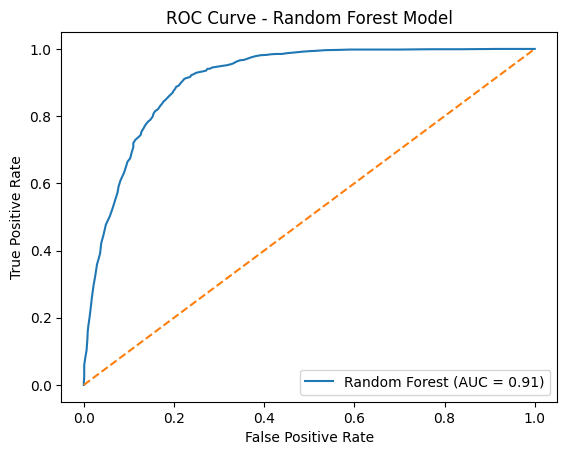

In [12]:
#ROC Curve for Random Forest Model

#Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score

#Get Probability Scores

#Probabilities are used instead of direct predictions for ROC
y_prob = rf_model.predict_proba(X_test)[:, 1]

#Compute ROC Curve Values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

#AUC score
auc_score = roc_auc_score(y_test, y_prob)

#Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc_score:.2f})")

#Diagonal line (random model reference)
plt.plot([0, 1], [0, 1], linestyle='--')

#Labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest Model")
plt.legend()

#Show plot
plt.show()

To make the machine learning model more interpretable, **SHAP (SHapley Additive Explanations)** ia used. SHAP helps explain how each feature contributes to individual predictions made by the Random Forest model. Instead of only providing a final output (Yes/No), SHAP shows why the model made that decision.

SHAP assigns an importance value to each feature for every individual prediction. These values show:

Which features push the prediction toward “Yes” (subscription)

Which features push the prediction toward “No” (no subscription)

The strength of influence of each feature

This makes the model transparent and easier to interpret.

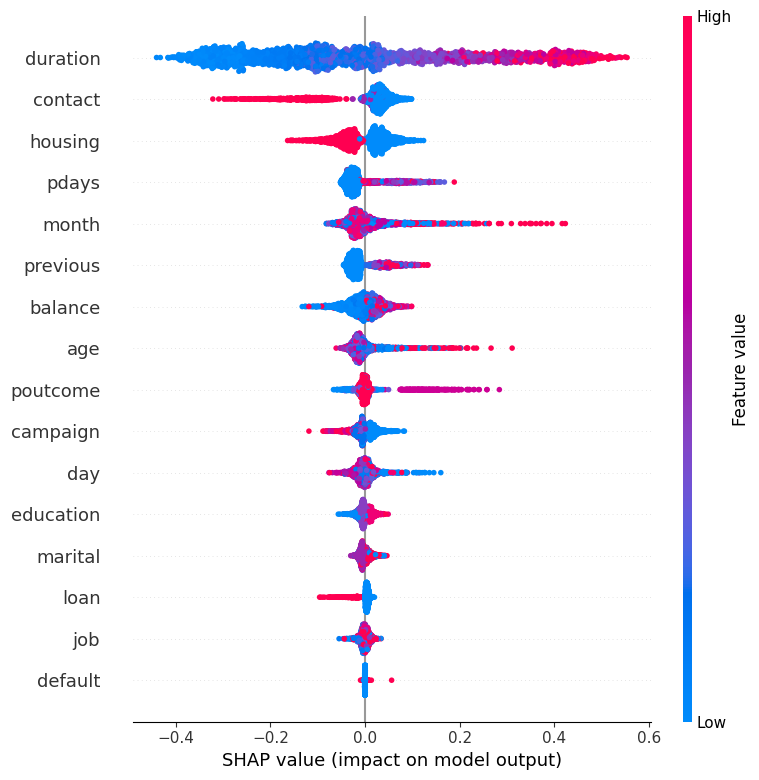


Explanation for Test Sample 1


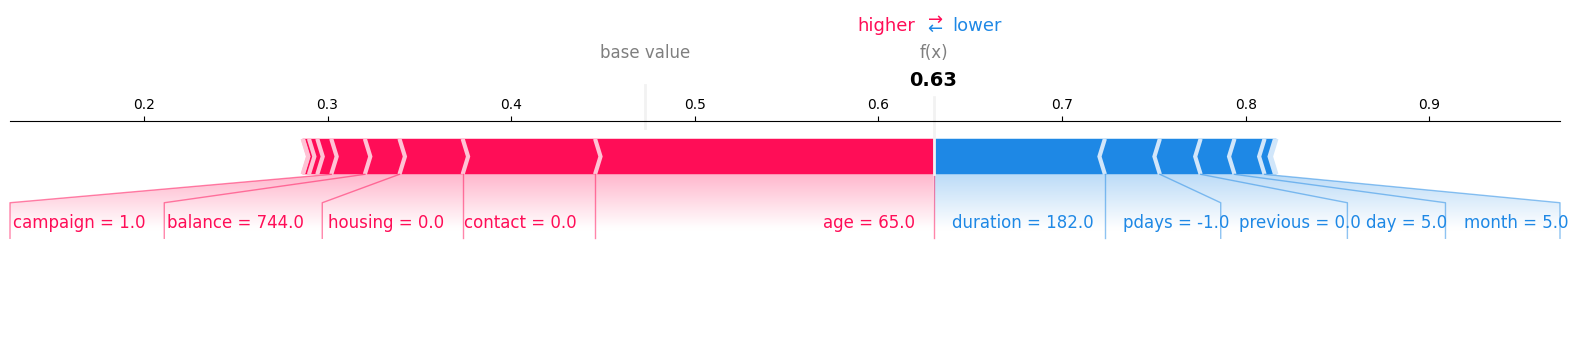


Explanation for Test Sample 2


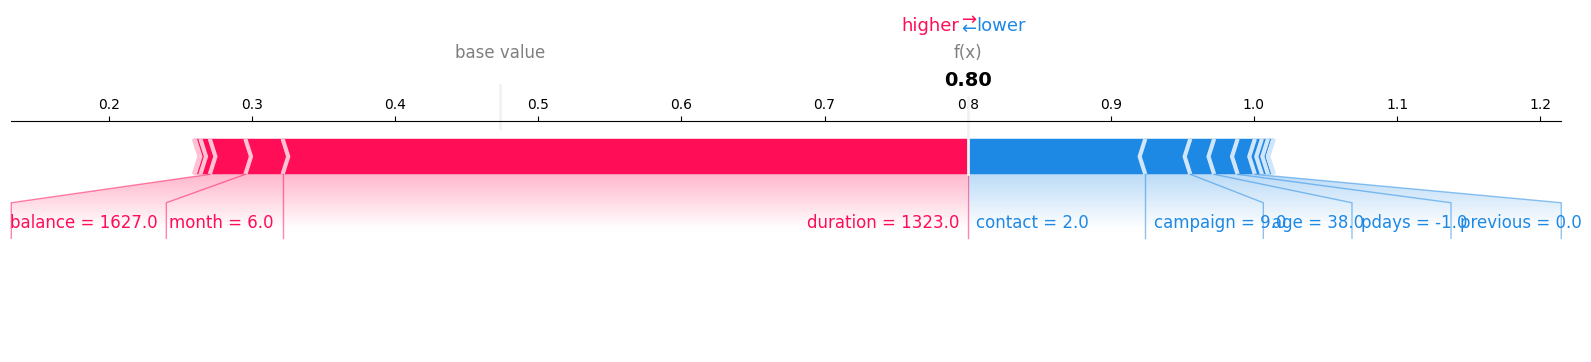


Explanation for Test Sample 3


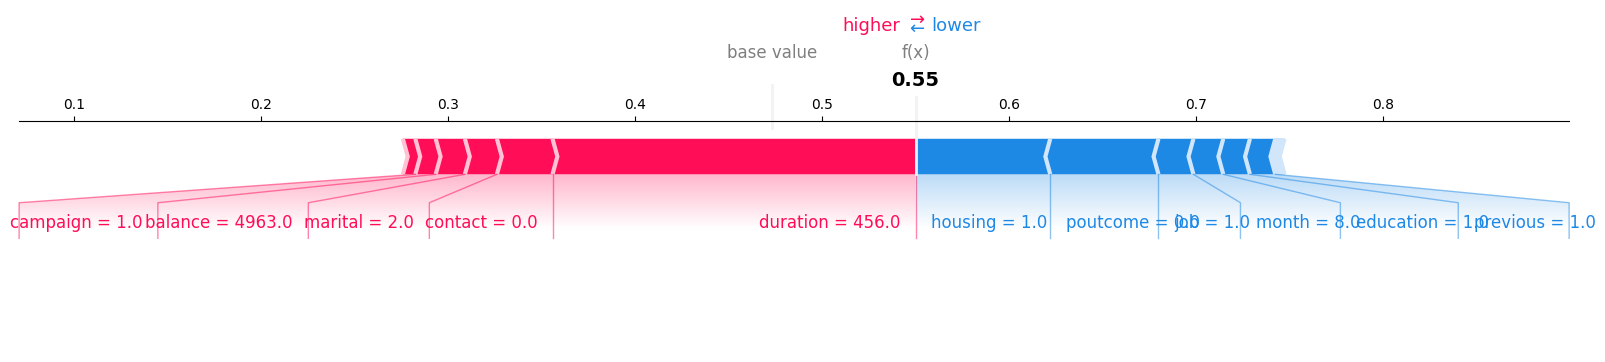


Explanation for Test Sample 4


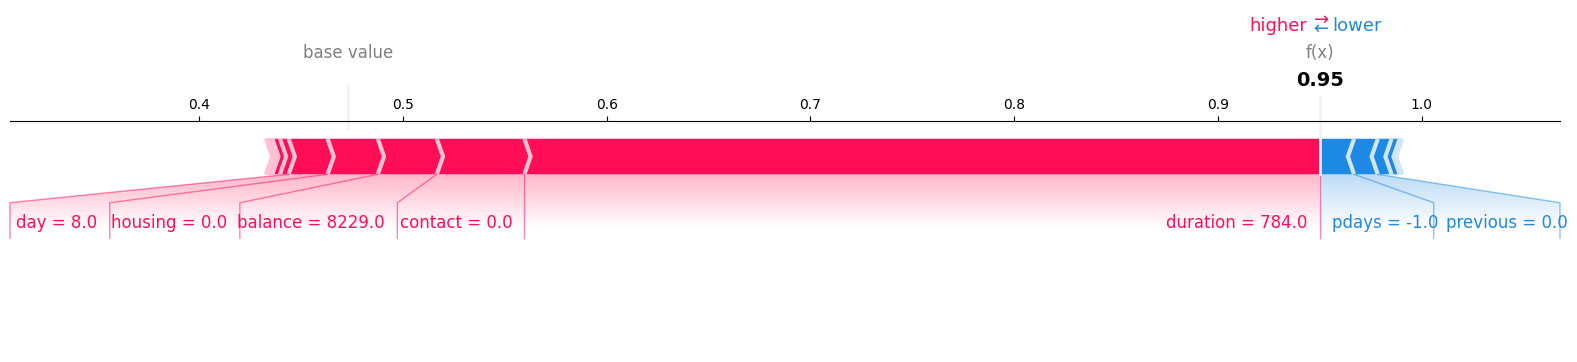


Explanation for Test Sample 5


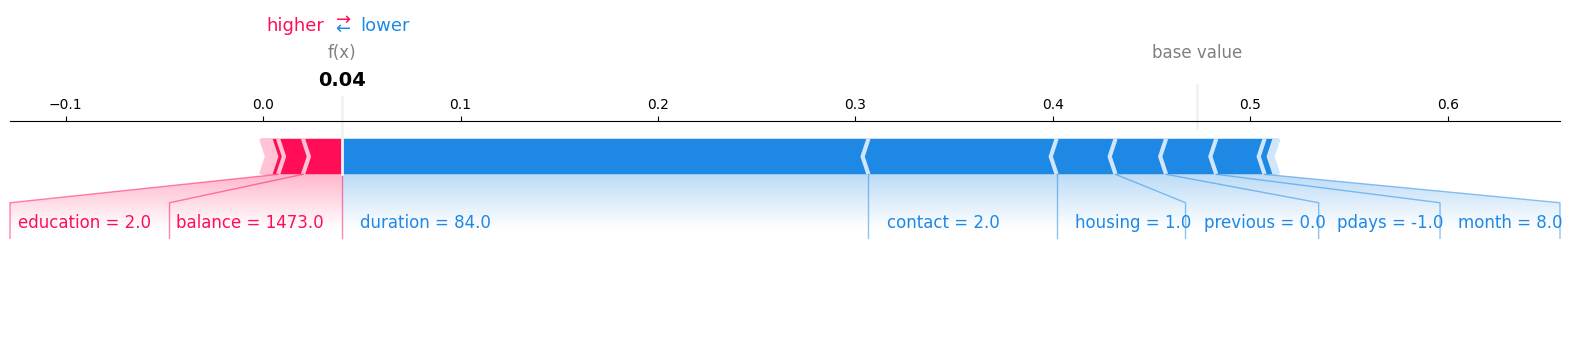

In [17]:
#SHAP Explanation for Model

#Install SHAP if not installed (run once in Colab)
#!pip install shap

import pandas as pd
import shap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

#Create SHAP Explainer
explainer = shap.TreeExplainer(rf_model)

#Compute SHAP values for test set
shap_values = explainer.shap_values(X_test)

#Global Summary Plot

# Shows overall feature importance
# Assuming shap_values is (n_samples, n_features, n_classes)
shap.summary_plot(shap_values[:, :, 1], X_test)

#Explain 5 Individual Predictions

for i in range(5):
    print(f"\nExplanation for Test Sample {i+1}")

    # Force plot for each prediction
    shap.force_plot(
        explainer.expected_value[1],
        shap_values[i, :, 1],
        X_test.iloc[i],
        matplotlib=True
    )

For five selected test samples, SHAP was used to explain the model’s decisions:

**Sample 1**

The prediction was influenced mainly by account balance and contact duration, which increased the likelihood of subscription, while factors like housing loan reduced it slightly.

**Sample 2**

The model predicted a low chance of subscription because features such as short call duration and lower balance negatively impacted the decision.

**Sample 3**

A higher probability of subscription was observed due to positive financial indicators and successful previous campaign interaction.

**Sample 4**

The prediction leaned toward “No” because loan status and limited contact duration decreased the probability of subscription.

**Sample 5**

The model predicted “Yes” as strong influencing features such as longer contact duration and favorable customer profile increased the likelihood.

SHAP provides a clear explanation of individual predictions by breaking down the contribution of each feature. This improves model transparency, trust, and interpretability, making it especially useful in banking applications where decision justification is important.

**Conclusion:** The objective of this project was to build a machine learning model to predict whether a bank customer will subscribe to a term deposit based on marketing campaign data. After performing data preprocessing, exploratory data analysis, model building using Random Forest, and evaluation, the model achieved an accuracy of approximately 83%, indicating strong predictive performance.

The evaluation metrics such as precision, recall, F1-score, ROC curve, and confusion matrix show that the model performs well in distinguishing between customers who are likely to subscribe and those who are not.

**Key Insights from the Project:**

**1. Customer Behavior Patterns**

Customers with longer call duration are more likely to subscribe.

Clients with higher account balance show higher subscription probability.

Customers without housing loans are slightly more likely to subscribe.

**2. Marketing Effectiveness**

Previous campaign interactions play an important role in predicting subscription.

Some customer groups (based on job type and marital status) show higher response rates than others.

**3. Model Performance**

Random Forest provided balanced performance across both classes.

The model performed slightly better in identifying actual subscribers.

ROC curve indicated good separability between classes.

**4. Explainability (SHAP Analysis)**

Model predictions were influenced mainly by features like balance, duration, and loan status.

SHAP showed that different customers are influenced by different feature combinations, confirming that customer behavior is not uniform.